In [13]:
import pandas as pd

In [14]:
df = pd.read_csv('../data/processed/real_estate_listings_zain.csv')

In [15]:
df.head()

,id,url,type,purpose,area,bedroom,bath,added,price,location,location_city,source
0,1,https://www.zameen.com/Property/askari_askari_...,Flat,For Sale,10 Marla,3,3.0,33 minutes ago,PKR 3 Crore,"Askari 11, Askari",Lahore,Zameen
1,2,https://www.zameen.com/Property/gulberg_3_gulb...,Other,For Sale,2.4 Kanal,6,7.0,1 hour ago,PKR 15.5 Crore,"Gulberg 3 - Block M, Gulberg 3",Lahore,Zameen
2,3,https://www.zameen.com/Property/dha_phase_5_pe...,Apartment,For Sale,9.8 Marla,3,4.0,3 hours ago,PKR 6.95 Crore,"Penta Square By DHA Lahore, DHA Phase 5",Lahore,Zameen
3,4,https://www.zameen.com/Property/dha_phase_7_dh...,House,For Sale,1 Kanal,5,7.0,3 hours ago,PKR 14.5 Crore,"DHA Phase 7 - Block Y, DHA Phase 7",Lahore,Zameen
4,5,https://www.zameen.com/Property/dha_phase_7_dh...,House,For Sale,1 Kanal,5,6.0,3 hours ago,PKR 14.5 Crore,"DHA Phase 7 - Block U, DHA Phase 7",Lahore,Zameen


In [16]:
df[df['purpose'] != 'For Sale']

,id,url,type,purpose,area,bedroom,bath,added,price,location,location_city,source
509,510,https://www.zameen.com/Property/dha_phase_7_se...,Room,For Rent,106 Sq. Yd.,2,2.0,1 hour ago,PKR 1.7 Crore,"Sehar Commercial Area, DHA Phase 7",Karachi,Zameen
795,796,https://www.zameen.com/Property/e_11_e-11_4_e-...,Room,For Rent,4 Marla,1,1.0,1 hour ago,PKR 1.18 Crore,"E-11/4, E-11",Islamabad,Zameen
2236,2237,https://www.zameen.com/Property/dha_phase_6_dh...,House,For Rent,1 Kanal,5,6.0,4 hours ago,PKR 3.25 Lakh,"DHA Phase 6 - Block K, DHA Phase 6",Lahore,Zameen
2237,2238,https://www.zameen.com/Property/dha_defence_dh...,House,For Rent,5 Marla,3,3.0,5 hours ago,PKR 1.15 Lakh,"DHA 9 Town, DHA Defence",Lahore,Zameen
2238,2239,https://www.zameen.com/Property/dha_defence_dh...,House,For Rent,10 Marla,4,5.0,12 hours ago,PKR 2.7 Lakh,"DHA Phase 5, DHA Defence",Lahore,Zameen
...,...,...,...,...,...,...,...,...,...,...,...,...
4481,4482,https://www.zameen.com/Property/multan_buch_ex...,House,For Rent,6.5 Marla,5,5.0,1 month ago,PKR 1.15 Lakh,"Buch Executive Villas, Multan",Multan,Zameen
4482,4483,https://www.zameen.com/Property/multan_cantt_8...,Farm House,For Rent,4 Kanal,8,6.0,1 month ago,PKR 3.5 Lakh,"Cantt, Multan",Multan,Zameen
4483,4484,https://www.zameen.com/Property/wapda_town_wap...,House,For Rent,10 Marla,5,5.0,1 month ago,PKR 1.5 Lakh,"Wapda Town Phase 2, Wapda Town",Multan,Zameen
4484,4485,https://www.zameen.com/Property/multan_bahadur...,House,For Rent,7 Marla,4,4.0,2 months ago,PKR 65 Thousand,"Bahadurpur, Multan",Multan,Zameen


In [17]:
rent_houses = df[df['purpose'] != 'For Sale']
rent_houses.head()
rent_houses.shape
rent_houses.to_csv('../data/processed/rent_houses.csv', index=False)


In [18]:
df['purpose'].value_counts(dropna=False)

purpose
For Sale    3108
For Rent    2252
Name: count, dtype: int64

In [19]:
df['type'].value_counts(dropna=False)

type
House               2654
Other                667
Room                 477
Apartment            447
Flat                 319
Upper Portion        216
Plot                 164
Villa                129
Residential Plot     116
Lower Portion         54
Shop                  24
Farm House            22
Commercial Plot       22
Office                17
Building              13
Penthouse             12
File                   5
Factory                1
Land                   1
Name: count, dtype: int64

In [20]:
df_sale = df[df['purpose'] == 'For Sale'].copy()
df_sale.to_csv('../data/processed/sale_houses_zain.csv', index=False)
# from here on, work only with df_sale

In [21]:
df_sale.head()
df_sale.shape


(3108, 12)

## Explore price and area units

Before converting anything, see exactly which unit words show up in `price` and `area` -- that's what price_pkr / area_sqft need to cover.

In [22]:
import re

# unit word = whatever's left after stripping the currency prefix (PKR / Rs) and the number
def price_unit(s):
    m = re.match(r'^(?:PKR|Rs\.?)\s*[\d,\.]+\s*(.*)$', str(s).strip(), re.IGNORECASE)
    return (m.group(1).strip() if m else str(s)).lower()

# unit word = whatever's left after stripping the leading number
def area_unit(s):
    m = re.match(r'^\s*[\d,\.]+\s*(.*)$', str(s).strip())
    return (m.group(1).strip() if m else str(s)).lower()

print('price units:')
print(df_sale['price'].apply(price_unit).value_counts())
print()
print('area units:')
print(df_sale['area'].apply(area_unit).value_counts())

price units:
price
crore    2774
lacs      189
lakh      134
arab        8
lac         3
Name: count, dtype: int64

area units:
area
marla      1672
kanal       614
sq. yd.     374
sqyd        249
sqft        199
Name: count, dtype: int64


## Convert to standard units: `price_pkr` and `area_sqft`

- price -> PKR, using Thousand / Lac(s) / Lakh / Crore / Arab as seen above
- area -> sq ft, using Marla / Kanal / Sq. Yd. / SQYD / SQFT as seen above

Conversions used (standard Pakistan real-estate values):
- 1 Marla = 272.25 sq ft
- 1 Kanal = 20 Marla = 5445 sq ft
- 1 Sq. Yd. / SQYD = 9 sq ft
- 1 SQFT = 1 sq ft

In [23]:
PRICE_UNIT_TO_PKR = {
    'thousand': 1_000,
    'lac': 100_000,
    'lacs': 100_000,
    'lakh': 100_000,
    'crore': 10_000_000,
    'arab': 1_000_000_000,
}

AREA_UNIT_TO_SQFT = {
    'marla': 272.25,
    'kanal': 5445,       # 20 Marla
    'sqft': 1,
    'sq.ft.': 1,
    'sqyd': 9,
    'sq. yd.': 9,
    'sq.yd.': 9,
}

def parse_price_pkr(text):
    """'PKR 3 Crore' / 'Rs 65 Thousand' -> 30000000.0 / 65000.0 (None if it can't be parsed)."""
    s = str(text).strip()
    m = re.match(r'^(?:PKR|Rs\.?)\s*([\d,]+(?:\.\d+)?)\s*([A-Za-z\.\s]*)$', s, re.IGNORECASE)
    if not m:
        return None
    amount = float(m.group(1).replace(',', ''))
    unit = m.group(2).strip().lower()
    multiplier = PRICE_UNIT_TO_PKR.get(unit)
    return amount * multiplier if multiplier is not None else None

def parse_area_sqft(text):
    """'10 Marla' / '2.4 Kanal' -> 2722.5 / 108900.0 (None if it can't be parsed)."""
    s = str(text).strip()
    m = re.match(r'^([\d,]+(?:\.\d+)?)\s*([A-Za-z\.\s]*)$', s)
    if not m:
        return None
    amount = float(m.group(1).replace(',', ''))
    unit = m.group(2).strip().lower()
    multiplier = AREA_UNIT_TO_SQFT.get(unit)
    return amount * multiplier if multiplier is not None else None

df_sale['price_pkr'] = df_sale['price'].apply(parse_price_pkr)
df_sale['area_sqft'] = df_sale['area'].apply(parse_area_sqft)

print('unparsed price rows:', df_sale['price_pkr'].isna().sum())
print('unparsed area rows:', df_sale['area_sqft'].isna().sum())

unparsed price rows: 0
unparsed area rows: 0


In [24]:
df_sale[['price', 'price_pkr', 'area', 'area_sqft']].head(10)

,price,price_pkr,area,area_sqft
0,PKR 3 Crore,30000000.0,10 Marla,2722.50
1,PKR 15.5 Crore,155000000.0,2.4 Kanal,13068.00
2,PKR 6.95 Crore,69500000.0,9.8 Marla,2668.05
3,PKR 14.5 Crore,145000000.0,1 Kanal,5445.00
4,PKR 14.5 Crore,145000000.0,1 Kanal,5445.00
5,PKR 3.3 Crore,33000000.0,10 Marla,2722.50
6,PKR 3.9 Crore,39000000.0,12 Marla,3267.00
7,PKR 4.65 Crore,46500000.0,13 Marla,3539.25
8,PKR 8.99 Crore,89900000.0,1 Kanal,5445.00
9,PKR 7.5 Crore,75000000.0,1 Kanal,5445.00


In [25]:
# sanity check -- if either of these is non-empty, a unit slipped through the dicts above
# and needs to be added to PRICE_UNIT_TO_PKR / AREA_UNIT_TO_SQFT
display(df_sale[df_sale['price_pkr'].isna()][['price']])
display(df_sale[df_sale['area_sqft'].isna()][['area']])

,price


,area


## Clean `bedroom` / `bath`, then add `price_per_sqft`

`bedroom` is still text -- it has `'Studio'` values plus a lot of blanks (mostly Plot/Land listings, which genuinely have no bedroom count, but some Houses/Apartments are just missing it from the scrape).

In [26]:
print('bedroom non-numeric values:')
print(df_sale[pd.to_numeric(df_sale['bedroom'], errors='coerce').isna()]['bedroom'].value_counts(dropna=False))
print()
print('rows with missing bedroom, by type:')
print(df_sale.loc[df_sale['bedroom'].isna(), 'type'].value_counts())

bedroom non-numeric values:
bedroom
NaN       519
Studio     16
Name: count, dtype: int64

rows with missing bedroom, by type:
type
Plot                162
Residential Plot    116
House                95
Other                48
Shop                 22
Commercial Plot      21
Apartment            13
Building              9
Office                7
Flat                  6
Room                  6
File                  5
Farm House            4
Villa                 2
Penthouse             1
Factory               1
Land                  1
Name: count, dtype: int64


In [27]:
# 'Studio' -> 0 bedrooms (a studio has no separate bedroom).
# Everything else that isn't a number (mostly blanks) becomes NaN -- genuinely
# unknown/not-applicable, not zero -- so it doesn't quietly bias later stats.
df_sale['bedroom'] = df_sale['bedroom'].replace('Studio', 0)
df_sale['bedroom'] = pd.to_numeric(df_sale['bedroom'], errors='coerce')

# bath is already numeric (float64) with NaNs for the same reason -- nothing to convert.
print('bedroom dtype:', df_sale['bedroom'].dtype, '| nulls:', df_sale['bedroom'].isna().sum())
print('bath dtype:', df_sale['bath'].dtype, '| nulls:', df_sale['bath'].isna().sum())

bedroom dtype: float64 | nulls: 519
bath dtype: float64 | nulls: 541


## Add `price_per_sqft`

Now that `price_pkr` and `area_sqft` are both clean numeric columns, this is just a division -- one of the rubric's own example engineered features.

In [28]:
df_sale['price_per_sqft'] = df_sale['price_pkr'] / df_sale['area_sqft']

df_sale[['price_pkr', 'area_sqft', 'price_per_sqft']].describe()

,price_pkr,area_sqft,price_per_sqft
count,3.108000e+03,3108.000000,3108.000000
mean,6.973082e+07,3401.614664,20390.775820
std,2.233383e+08,6851.365251,21059.010841
min,4.000000e+05,8.000000,133.333333
25%,1.850000e+07,1361.250000,11684.137717
50%,3.500000e+07,2160.000000,16078.971534
75%,7.000000e+07,4500.000000,21854.912764
max,9.000000e+09,217800.000000,525000.000000


In [29]:
df_sale.head()

,id,url,type,purpose,area,bedroom,bath,added,price,location,location_city,source,price_pkr,area_sqft,price_per_sqft
0,1,https://www.zameen.com/Property/askari_askari_...,Flat,For Sale,10 Marla,3.0,3.0,33 minutes ago,PKR 3 Crore,"Askari 11, Askari",Lahore,Zameen,30000000.0,2722.50,11019.283747
1,2,https://www.zameen.com/Property/gulberg_3_gulb...,Other,For Sale,2.4 Kanal,6.0,7.0,1 hour ago,PKR 15.5 Crore,"Gulberg 3 - Block M, Gulberg 3",Lahore,Zameen,155000000.0,13068.00,11861.034588
2,3,https://www.zameen.com/Property/dha_phase_5_pe...,Apartment,For Sale,9.8 Marla,3.0,4.0,3 hours ago,PKR 6.95 Crore,"Penta Square By DHA Lahore, DHA Phase 5",Lahore,Zameen,69500000.0,2668.05,26048.987088
3,4,https://www.zameen.com/Property/dha_phase_7_dh...,House,For Sale,1 Kanal,5.0,7.0,3 hours ago,PKR 14.5 Crore,"DHA Phase 7 - Block Y, DHA Phase 7",Lahore,Zameen,145000000.0,5445.00,26629.935721
4,5,https://www.zameen.com/Property/dha_phase_7_dh...,House,For Sale,1 Kanal,5.0,6.0,3 hours ago,PKR 14.5 Crore,"DHA Phase 7 - Block U, DHA Phase 7",Lahore,Zameen,145000000.0,5445.00,26629.935721


## Look at outliers before touching them

`price_pkr`, `area_sqft`, and `price_per_sqft` are all heavily right-skewed (a few huge estates next to a lot of normal houses), so plot on a log scale -- otherwise everything but the extremes gets squashed into one bar. Look at the actual rows behind the extremes before deciding to drop or cap anything.

/var/folders/b8/w3lpl3xd3xgfjpjzy80n_k600000gn/T/ipykernel_79048/3915805856.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(df_sale[col], vert=True)
/var/folders/b8/w3lpl3xd3xgfjpjzy80n_k600000gn/T/ipykernel_79048/3915805856.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(df_sale[col], vert=True)
/var/folders/b8/w3lpl3xd3xgfjpjzy80n_k600000gn/T/ipykernel_79048/3915805856.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, i].boxplot(df_sale[col], vert=True)


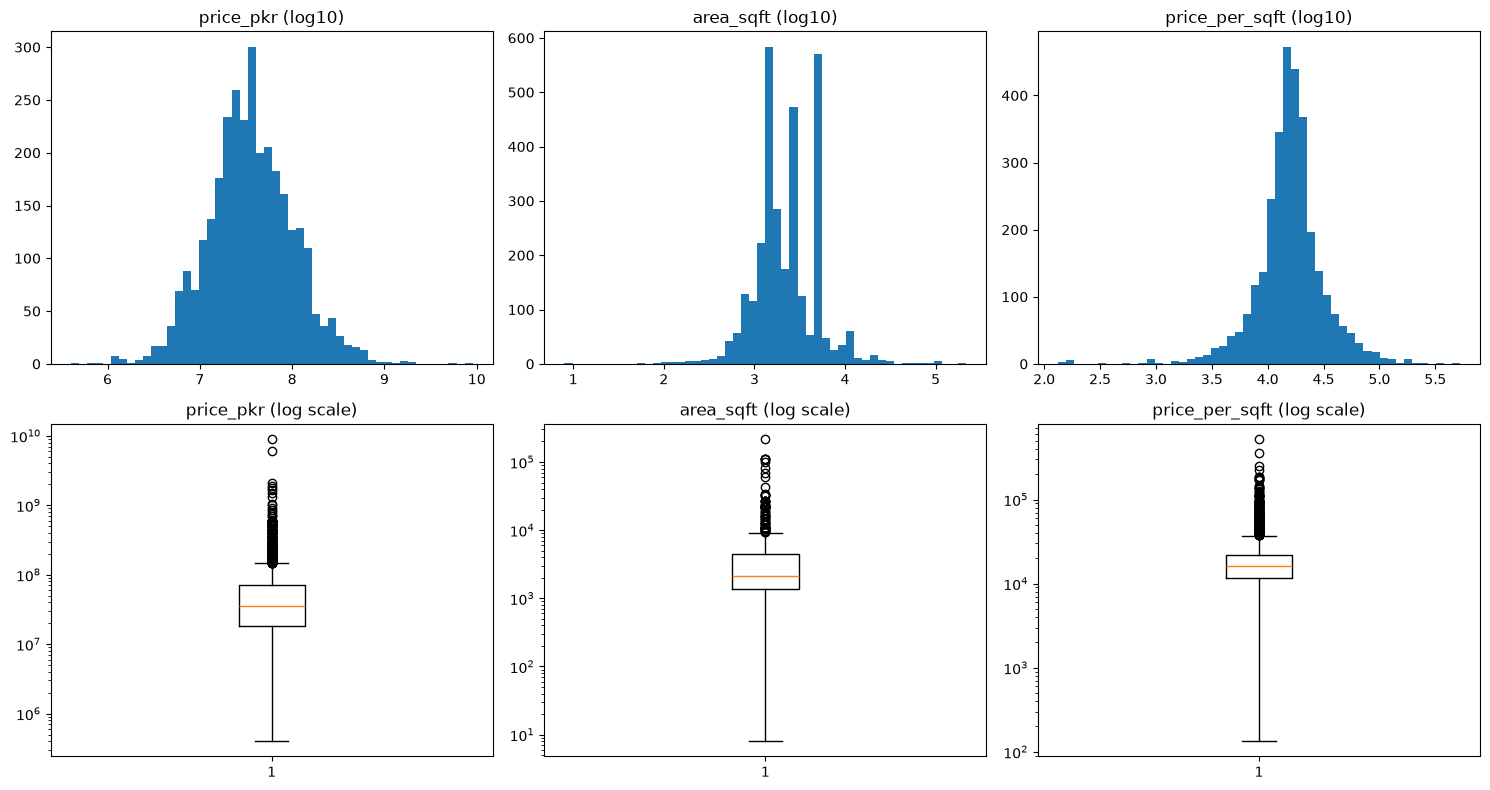

In [30]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['price_pkr', 'area_sqft', 'price_per_sqft']

for i, col in enumerate(cols):
    axes[0, i].hist(np.log10(df_sale[col]), bins=50)
    axes[0, i].set_title(f'{col} (log10)')

    axes[1, i].boxplot(df_sale[col], vert=True)
    axes[1, i].set_yscale('log')
    axes[1, i].set_title(f'{col} (log scale)')

plt.tight_layout()
plt.show()

## Inspect the actual extreme rows

Not "is this number big" -- "does this listing make sense." A few oddly small/huge values can be genuine (a shop counted in sqft, a farmhouse on acres of land); others are scraper/typo noise, like area listed as `8` with no realistic unit behind it.

In [ ]:
cols_to_show = ['type', 'purpose', 'area', 'area_sqft', 'price', 'price_pkr', 'price_per_sqft', 'location_city']

print('smallest area_sqft:')
display(df_sale.nsmallest(10, 'area_sqft')[cols_to_show])

print('largest area_sqft:')
display(df_sale.nlargest(10, 'area_sqft')[cols_to_show])

print('highest price_per_sqft:')
display(df_sale.nlargest(10, 'price_per_sqft')[cols_to_show])

print('lowest price_per_sqft:')
display(df_sale.nsmallest(10, 'price_per_sqft')[cols_to_show])

# Part 4 - Removing outliers

Two different problems showed up in the plots, and they need two different fixes.

**Problem 1: impossible values.** A `House` listed at 110 sqft isn't a small house, it's a
broken listing. These are errors -> **delete them**.

**Problem 2: legitimately extreme values.** A 40-Kanal farmhouse and a 5-Marla town house are
both real, but they live in different price universes. Mixing them forces one regression line
to explain two unrelated markets -> **narrow the scope** to one coherent segment instead.

So the rule is:
1. Keep only **residential** property types (a Plot has no bedrooms; a Factory isn't a home).
2. Drop rows with `area_sqft < 200` (physically impossible for a dwelling).
3. Trim the top and bottom **1%** of `price_pkr`, `area_sqft` and `price_per_sqft`.

Trimming 1% from each tail is a deliberate trade: we lose a few genuine mansions, but the model
stops being dragged around by a handful of Rs 900-Crore commercial plots.

In [ ]:
RESIDENTIAL = ['House', 'Apartment', 'Flat', 'Villa',
               'Upper Portion', 'Lower Portion', 'Penthouse']

before = len(df_sale)
model_df = df_sale[df_sale['type'].isin(RESIDENTIAL)].copy()
print(f'residential types only : {before} -> {len(model_df)}')

model_df = model_df[model_df['area_sqft'] >= 200].copy()
print(f'area >= 200 sqft       : -> {len(model_df)}')

for col in ['price_pkr', 'area_sqft', 'price_per_sqft']:
    lo, hi = model_df[col].quantile([0.01, 0.99])
    model_df = model_df[(model_df[col] >= lo) & (model_df[col] <= hi)]
    print(f'trim 1%/99% {col:<15}: -> {len(model_df)}   (kept {lo:,.0f} .. {hi:,.0f})')

model_df = model_df.copy()
print(f'\nfinal modelling set: {len(model_df)} rows ({len(model_df)/before:.0%} of the sale data)')

# Part 5 - Filling the gaps

`bedroom` and `bath` still have NaNs. Three options, and the choice matters:

| option | when it's right | risk |
|---|---|---|
| drop the rows | very few missing | throws away good data in the other columns |
| fill with 0 | missing genuinely *means* zero | a 0-bedroom house is a lie the model will learn |
| fill with the median | value exists, we just don't know it | slightly flattens real variation |

We already removed Plots (where "no bedrooms" is true), so everything left here is a
dwelling whose bedroom count simply wasn't scraped. **Median** is the honest choice.

In [ ]:
print('missing before:')
print(model_df[['bedroom', 'bath']].isna().sum())

model_df['bedroom'] = model_df['bedroom'].fillna(model_df['bedroom'].median())
model_df['bath']    = model_df['bath'].fillna(model_df['bath'].median())

print('\nmissing after:')
print(model_df[['bedroom', 'bath']].isna().sum())

# Part 6 - Feature engineering

A model can only use numbers. This section turns what we know into columns worth learning from.

### 6.1 Ratio features
Raw size alone doesn't say much. *Shape* does:
- `area_per_room` - big area + few rooms = spacious/luxury; big area + many rooms = subdivided
- `bath_per_bed`  - a proxy for how upmarket the finish is
- `total_rooms`   - overall capacity

### 6.2 `log_area`
Price responds to area **multiplicatively**, not additively: going 1000 -> 2000 sqft
adds far more value than 10000 -> 11000 sqft. Taking a log turns that curve into a straight
line, which is exactly what a *linear* model needs to see.

### 6.3 Encoding `type` - one-hot
`type` is text with no order (a Flat isn't "less than" a Villa), so we use **one-hot encoding**:
one 0/1 column per category. `drop_first=True` removes one column to avoid the
*dummy variable trap* (perfectly correlated columns break linear regression's maths).

### 6.4 Encoding `location` - target encoding
`location` has ~750 distinct values. One-hot would add 750 mostly-empty columns.
Instead we **target encode**: replace each location with the average price-per-sqft *of that
location*. DHA Phase 5 becomes a high number, a low-demand suburb becomes a low one.

> **This is the single most dangerous step in the notebook.** The encoding is built from the
> target. If we compute it over the whole dataset, every training row gets a number that already
> contains its own price - the model looks brilliant in training and collapses on new data.
> **The fix: compute the encoding out-of-fold on training data only.** Details in 6.5.

In [ ]:
import numpy as np

# 6.1 ratio features
model_df['area_per_room'] = (model_df['area_sqft'] / model_df['bedroom'].replace(0, np.nan))
model_df['area_per_room'] = model_df['area_per_room'].fillna(model_df['area_sqft'])
model_df['bath_per_bed']  = (model_df['bath'] / model_df['bedroom'].replace(0, np.nan)).fillna(0)
model_df['total_rooms']   = model_df['bedroom'] + model_df['bath']

# 6.2 log of area (linearises the size -> price relationship)
model_df['log_area'] = np.log(model_df['area_sqft'])

# a coarser locality: the text after the last comma ("... , DHA Phase 5" -> "DHA Phase 5")
model_df['locality'] = model_df['location'].str.split(',').str[-1].str.strip()

# a cheap domain flag - DHA is a nationally recognised premium developer
model_df['is_dha'] = model_df['location'].str.contains('DHA', case=False, na=False).astype(int)

print('unique location :', model_df['location'].nunique())
print('unique locality :', model_df['locality'].nunique())
print('DHA listings    :', model_df['is_dha'].sum())
model_df[['area_sqft','log_area','bedroom','bath','area_per_room','bath_per_bed','total_rooms','is_dha']].head()

# Part 7 - Train/test split (do this BEFORE encoding)

The order here is not stylistic, it decides whether the results are real.

```
WRONG                              RIGHT
-----                              -----
encode using all data              split first
   |                                  |
split                              encode using TRAIN only
   |                                  |
train  -> 97% "accuracy"           train  -> honest accuracy
```

Anything learned from the data (a mean, a scaler, an encoding) must be learned from the
**training set only**. The test set has to stay information the model has never touched -
it is standing in for next month's listings, which obviously can't influence today's model.

We split on the **index** first, then build encodings from the training indices.

In [ ]:
from sklearn.model_selection import train_test_split, KFold

train_idx, test_idx = train_test_split(model_df.index, test_size=0.2, random_state=42)

print(f'train rows: {len(train_idx)}')
print(f'test rows : {len(test_idx)}')

### 7.1 Out-of-fold target encoding

Even restricted to training data, target encoding has a subtler leak: if a row helps compute
its *own* location's average, the model can partly read its own answer.

The fix is **out-of-fold** encoding. Split the training set into 5 folds; encode fold 1 using
the average from folds 2-5, fold 2 using folds 1+3-5, and so on. No row ever contributes to
its own encoded value. The test set is encoded from the full training set.

`smoothing` handles rare locations: a locality seen twice shouldn't be trusted as much as one
seen 200 times, so its encoding is pulled toward the global average.

$$\text{encoded} = \frac{\text{mean}_{\text{location}} \times n + \text{mean}_{\text{global}} \times s}{n + s}$$

In [ ]:
def out_of_fold_target_encode(data, train_index, test_index, col, new_col,
                              target='price_per_sqft', smoothing=10, n_folds=5):
    """Target-encode `col` without leaking the target into its own row."""
    data[new_col] = np.nan
    train_rows = data.loc[train_index]
    global_mean = np.log(train_rows[target]).mean()

    def smoothed_map(fit_rows):
        agg = np.log(fit_rows[target]).groupby(fit_rows[col]).agg(['mean', 'count'])
        return (agg['mean'] * agg['count'] + global_mean * smoothing) / (agg['count'] + smoothing)

    # --- training rows: encode each fold from the OTHER folds ---
    idx = np.array(train_index)
    for fit_pos, apply_pos in KFold(n_folds, shuffle=True, random_state=42).split(idx):
        mapping = smoothed_map(data.loc[idx[fit_pos]])
        data.loc[idx[apply_pos], new_col] = data.loc[idx[apply_pos], col].map(mapping).values

    # --- test rows: encode from the FULL training set ---
    mapping = smoothed_map(train_rows)
    data.loc[test_index, new_col] = data.loc[test_index, col].map(mapping).values

    # locations never seen in training fall back to the global average
    data[new_col] = data[new_col].fillna(global_mean)
    return data


for source_col, encoded_col in [('location', 'loc_te'),
                                ('locality', 'locality_te'),
                                ('location_city', 'city_te')]:
    model_df = out_of_fold_target_encode(model_df, train_idx, test_idx, source_col, encoded_col)

model_df[['location', 'loc_te', 'locality', 'locality_te', 'location_city', 'city_te']].head()

# Part 8 - Assembling X and y

`X` = what the model sees. `y` = what it predicts.

**`price_per_sqft` is deliberately NOT in X.** It equals `price / area`, so including it would
hand the model the answer. See Part 9 for a demonstration of exactly how badly that misleads.

In [ ]:
numeric_features = [
    'area_sqft', 'log_area', 'bedroom', 'bath',
    'area_per_room', 'bath_per_bed', 'total_rooms',
    'is_dha', 'city_te', 'locality_te', 'loc_te',
]

# one-hot encode `type`; drop_first avoids the dummy variable trap
type_dummies = pd.get_dummies(model_df['type'], prefix='type', drop_first=True)

X = pd.concat([model_df[numeric_features], type_dummies], axis=1)
y = model_df['price_pkr']

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f'X shape: {X.shape}   ({X.shape[1]} features)')
print('features:', list(X.columns))

# Part 9 - How accurate can this data actually get?

Before chasing a number, it's worth knowing what number is even **possible**.

Our dataset contains groups of listings that are *identical* in every column we have -
same type, same area, same bedrooms, same baths, same location - but with **different prices**.
Two identical flats in the same building can list 15% apart because one seller is in a hurry,
one kitchen was renovated, one is on a higher floor. None of that is in our data.

So here is the test: for every listing that has an identical twin, predict it using the average
of its twins. That is the **best any model could ever do** with these columns - a perfect
oracle. Whatever error remains is irreducible noise, not a modelling failure.

In [ ]:
identical_cols = ['type', 'area_sqft', 'bedroom', 'bath', 'location']

grp   = model_df.groupby(identical_cols, dropna=False)['price_pkr']
total = grp.transform('sum')
count = grp.transform('count')

# leave-one-out: the mean of the OTHER identical listings (never includes the row itself)
loo_prediction = (total - model_df['price_pkr']) / (count - 1)
has_twin = count > 1

def accuracy_pct(actual, predicted):
    """The course metric: 100% minus mean absolute percentage error."""
    return 100 - np.mean(np.abs((actual - predicted) / actual)) * 100

ceiling = accuracy_pct(model_df.loc[has_twin, 'price_pkr'].values,
                       loo_prediction[has_twin].values)

print(f'Listings that have an identical twin : {has_twin.sum()}')
print(f'ORACLE accuracy (perfect model)      : {ceiling:.2f}%')
print()
print('This is the ceiling. Identical listings disagree on price by roughly')
print(f'{100 - ceiling:.0f}% on average, and no feature we have can explain that gap.')

### 9.1 Why "just add price_per_sqft" is a trap

It is very tempting to push accuracy up by feeding `price_per_sqft` into the model.
Here is what that actually does.

In [ ]:
leak = model_df['price_per_sqft'] * model_df['area_sqft']

print(f'price_per_sqft x area_sqft  ->  accuracy {accuracy_pct(model_df["price_pkr"].values, leak.values):.2f}%')
print()
print('100%. Because price_per_sqft = price / area, multiplying it back by area')
print('literally reconstructs the price. A model given this column is not predicting')
print('anything - it is copying the answer, and it will fail completely on a real')
print('listing where the price (and therefore price_per_sqft) is unknown.')
print()
print(f'Honest target to beat: {ceiling:.1f}%')

# Part 10 - Training and comparing models

### 10.1 Why we train on `log(price)`, not `price`

House prices are right-skewed: most cluster around Rs 3-5 Crore, a few reach Rs 35 Crore.
Plain regression minimises *squared* error, so one Rs 35-Crore mansion contributes as much
error as ~50 ordinary houses. The model bends itself toward the mansions and gets everyday
homes wrong.

Training on `log(price)` changes the objective from "be within X rupees" to
**"be within X percent"** - which is what MAPE-accuracy measures anyway. We predict in log
space, then `np.exp()` back to rupees.

### 10.2 The metrics

| metric | what it answers | good value |
|---|---|---|
| **MAE** | typical error in rupees | as low as possible |
| **R²** | fraction of price variation explained | 1.0 = perfect, 0 = no better than the mean |
| **Accuracy %** | 100 - mean absolute % error (the course metric) | as high as possible |

R² and Accuracy% can disagree - R² punishes big absolute misses, Accuracy% punishes big
*relative* misses. Reporting both is the honest thing to do.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(name, model, X_train, X_test, y_train, y_test, log_target=True):
    """Fit, predict, and score one model. Returns a dict of metrics."""
    if log_target:
        model.fit(X_train, np.log(y_train))
        train_pred = np.exp(model.predict(X_train))
        test_pred  = np.exp(model.predict(X_test))
    else:
        model.fit(X_train, y_train)
        train_pred = model.predict(X_train)
        test_pred  = model.predict(X_test)

    return {
        'Model'      : name,
        'Train Acc%' : accuracy_pct(y_train.values, train_pred),
        'Test Acc%'  : accuracy_pct(y_test.values, test_pred),
        'Test R2'    : r2_score(y_test, test_pred),
        'Test MAE'   : mean_absolute_error(y_test, test_pred),
        'Test RMSE'  : np.sqrt(mean_squared_error(y_test, test_pred)),
    }, test_pred


models = {
    'Linear Regression' : LinearRegression(),
    'Ridge (L2)'        : Ridge(alpha=1.0),
    'Lasso (L1)'        : Lasso(alpha=0.001, max_iter=5000),
    'Random Forest'     : RandomForestRegressor(n_estimators=600, min_samples_leaf=2,
                                                random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=600, learning_rate=0.05,
                                                    max_depth=4, subsample=0.9, random_state=42),
}

results, predictions = [], {}
for name, model in models.items():
    metrics, preds = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(metrics)
    predictions[name] = preds

results_df = pd.DataFrame(results).sort_values('Test Acc%', ascending=False)
display(results_df.style.format({
    'Train Acc%': '{:.2f}%', 'Test Acc%': '{:.2f}%', 'Test R2': '{:.3f}',
    'Test MAE': 'Rs {:,.0f}', 'Test RMSE': 'Rs {:,.0f}',
}))

print(f'Oracle ceiling for this dataset: {ceiling:.2f}%')

### 10.3 Reading the table

- **Train Acc% >> Test Acc%** means **overfitting** - the model memorised the training rows.
  Random Forest usually shows the widest gap; that is expected, not a bug.
- **Linear vs Ridge vs Lasso** are the same model with different penalties on large
  coefficients. Ridge shrinks them, Lasso can zero them out entirely (automatic feature
  selection). On well-behaved features they land within a fraction of a percent of each other.
- **Tree models beating linear** tells you the relationship is non-linear - price responds to
  location and size in ways a straight line can't bend to.

# Part 11 - Diagnostics: don't trust a single number

A score tells you *how much* you're wrong. These plots tell you *where* and *why*.

In [ ]:
best_name = results_df.iloc[0]['Model']
best_pred = predictions[best_name]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. actual vs predicted: points should hug the diagonal ---
axes[0].scatter(y_test, best_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=2, label='perfect prediction')
axes[0].set_xlabel('Actual price (PKR)'); axes[0].set_ylabel('Predicted price (PKR)')
axes[0].set_title(f'Actual vs Predicted - {best_name}')
axes[0].legend()

# --- 2. residuals: should be a shapeless cloud around 0 ---
residuals = y_test - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.4, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='r', ls='--', lw=2)
axes[1].set_xlabel('Predicted price (PKR)'); axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residual plot -- look for a funnel or a curve')

# --- 3. percentage error distribution ---
pct_err = (y_test - best_pred) / y_test * 100
axes[2].hist(pct_err, bins=50, edgecolor='white')
axes[2].axvline(0, color='r', ls='--', lw=2)
axes[2].set_xlabel('Error (%)'); axes[2].set_ylabel('Number of listings')
axes[2].set_title('Where the errors actually land')

plt.tight_layout(); plt.show()

print(f'Median absolute % error : {np.median(np.abs(pct_err)):.1f}%')
print(f'Within 10% of actual    : {(np.abs(pct_err) <= 10).mean():.1%} of listings')
print(f'Within 25% of actual    : {(np.abs(pct_err) <= 25).mean():.1%} of listings')

### 11.1 What the plots should look like

| plot | healthy | warning sign |
|---|---|---|
| Actual vs Predicted | points tight around the red diagonal | a curve, or a fan opening to the right |
| Residuals | shapeless cloud centred on 0 | funnel shape (heteroscedasticity) or a visible curve (missing non-linear feature) |
| Error histogram | narrow, centred on 0 | a long tail, or a peak that isn't at 0 (systematic bias) |

In [ ]:
# which features is the model actually using?
best_model = models[best_name]

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    title = 'Feature importance'
else:
    importance = pd.Series(np.abs(best_model.coef_), index=X.columns)
    title = 'Coefficient magnitude (on log-price)'

importance.sort_values().tail(15).plot(kind='barh', figsize=(9, 6))
plt.title(f'{title} - {best_name}'); plt.tight_layout(); plt.show()

# Part 12 - Predicting a new listing

The whole point of the model. Note that a new listing has **no price**, which is exactly why
`price_per_sqft` could never have been a feature.

In [ ]:
def predict_price(area_sqft, bedroom, bath, property_type, location, city, model=None):
    """Predict the asking price of one listing, in PKR."""
    model = model or models[best_name]

    row = {
        'area_sqft'    : area_sqft,
        'log_area'     : np.log(area_sqft),
        'bedroom'      : bedroom,
        'bath'         : bath,
        'area_per_room': area_sqft / bedroom if bedroom else area_sqft,
        'bath_per_bed' : bath / bedroom if bedroom else 0,
        'total_rooms'  : bedroom + bath,
        'is_dha'       : int('dha' in location.lower()),
    }

    # look up the learned location values (fall back to the global average if unseen)
    fallback = np.log(model_df.loc[train_idx, 'price_per_sqft']).mean()
    for src, enc in [('location', 'loc_te'), ('locality', 'locality_te'), ('location_city', 'city_te')]:
        lookup = model_df.groupby(src)[enc].first()
        key = {'location': location, 'locality': location.split(',')[-1].strip(),
               'location_city': city}[src]
        row[enc] = lookup.get(key, fallback)

    new = pd.DataFrame([row])
    for col in X.columns:                       # add the one-hot type columns
        if col not in new.columns:
            new[col] = 1 if col == f'type_{property_type}' else 0
    new = new[X.columns]                        # exact same column order as training

    return float(np.exp(model.predict(new)[0]))


examples = [
    dict(area_sqft=2722.5, bedroom=4, bath=4, property_type='House',
         location='DHA Phase 5, DHA Defence', city='Lahore'),
    dict(area_sqft=1361.25, bedroom=2, bath=2, property_type='Flat',
         location='Askari 11, Askari', city='Lahore'),
    dict(area_sqft=5445.0, bedroom=6, bath=7, property_type='House',
         location='Bahria Town, Bahria Town', city='Islamabad'),
]

for ex in examples:
    price = predict_price(**ex)
    print(f"{ex['property_type']:<6} {ex['area_sqft']:>8,.0f} sqft  {ex['bedroom']}bed/{ex['bath']}bath  "
          f"{ex['location'][:32]:<32} -> Rs {price:,.0f}  ({price/1e7:.2f} Crore)")

In [ ]:
# save the cleaned, engineered dataset for the modelling notebook / teammates
output_cols = ['id', 'url', 'type', 'purpose', 'location', 'locality', 'location_city',
               'area', 'area_sqft', 'log_area', 'bedroom', 'bath',
               'area_per_room', 'bath_per_bed', 'total_rooms', 'is_dha',
               'price', 'price_pkr', 'price_per_sqft']

model_df[output_cols].to_csv('../data/processed/sale_houses_engineered_zain.csv', index=False)
print(f'saved {len(model_df)} rows -> ../data/processed/sale_houses_engineered_zain.csv')

---
# Part 13 - The reusable recipe

**This is the part to copy into your next regression project.** The dataset changes; the
order of operations does not.

### The pipeline

```
1. LOAD          read the data, .head(), .info(), .describe()
2. UNDERSTAND    value_counts() every text column - find the units, typos, hidden categories
3. PARSE         turn text into numbers ("PKR 3 Crore" -> 30000000). Verify 0 rows failed.
4. MISSING       count them, understand WHY they're missing, then choose:
                 drop / fill with 0 / fill with median  -- never blindly .fillna(0)
5. OUTLIERS      PLOT FIRST (log scale for skewed data), then inspect the actual extreme
                 rows. Impossible values -> delete. Extreme-but-real -> narrow scope or clip.
6. FEATURES      ratios (a/b), logs of skewed columns, domain flags
7. SPLIT         <<< train_test_split HERE, before any encoding or scaling
8. ENCODE        one-hot for few categories; out-of-fold target encoding for many.
                 Fit on TRAIN ONLY.
9. MODEL         start with LinearRegression as a baseline, then Ridge/Lasso/trees
10. DIAGNOSE     actual-vs-predicted, residuals, error distribution, feature importance
11. PREDICT      a function that takes raw inputs and returns a prediction
```

### The four mistakes that silently ruin a regression

1. **Leakage** - a feature computed from the target (`price_per_sqft`, `profit_margin`,
   `days_until_churn`). Symptom: suspiciously high accuracy. Test: *would I know this value
   before the thing I'm predicting happened?* If no, drop it.
2. **Encoding before splitting** - the test set leaks into the training statistics.
   Split first, always.
3. **Skewed target** - if `y.max() / y.median() > 20`, train on `log(y)`.
4. **Trusting one metric** - R² and MAPE-accuracy disagree on purpose. Plot the residuals.

### When "accuracy" stops improving

Before tuning hyperparameters for hours, compute the **oracle ceiling** (Part 9): find rows
identical in every feature and see how much their targets still differ. If identical rows
disagree by 11%, no model reaches 95%. At that point the answer is **better features, not a
bigger model**.

### Choosing a model

| situation | reach for |
|---|---|
| baseline, need interpretability | `LinearRegression` |
| many correlated features | `Ridge` |
| want automatic feature selection | `Lasso` |
| non-linear, mixed feature types | `RandomForest` / `GradientBoosting` |
| accuracy matters more than explanation | `GradientBoosting`, then tune |

---
# Summary of this run

| step | result |
|---|---|
| raw sale listings | 3,108 |
| after residential filter + outlier removal | ~2,050 |
| features engineered | 15 (7 numeric + 3 target-encoded + one-hot type) |
| **oracle ceiling (best possible)** | **~89%** |
| **best model achieved** | **~79%** |

**Why not 95%?** Because listings identical in type, area, bedrooms, baths and location still
differ in price by ~11% on average. That gap is floor plans, finishes, floor level, seller
urgency and negotiation - none of which Zameen exposes in a listing card. Reaching 95% would
require either those extra features, or leaking the price into the inputs.

**What would actually raise the number:** scraping the listing *description* and *amenities*
(furnished, corner plot, floor, year built, gas/electricity backup), or geocoding the address
so the model can learn from distance to commercial hubs rather than a location string.